# SDGlove per-class visualization

- Randomly select one participant from `GLOVE/SDGlove`.
- For each class, randomly pick one instance file for that participant and
plot all sensor channels.
- All classes shown together in a single figure (one subplot per class).

In [1]:
import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SDGLOVE_DIR = "./SDGlove"
SENSOR_COLS = [f"sensor_{i}" for i in range(1, 11)]
ALL_CLASSES = [f"S{i}" for i in range(1, 8)] + [f"D{i}" for i in range(1, 6)]

RANDOM_SEED = None  
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

In [2]:
# Randomly select one participant
participants = sorted(d for d in os.listdir(SDGLOVE_DIR) if os.path.isdir(os.path.join(SDGLOVE_DIR, d)))
participant = random.choice(participants)
participant_dir = os.path.join(SDGLOVE_DIR, participant)
print(f"Selected participant: {participant}")

Selected participant: s25


In [3]:
# Randomly select one instance
def pick_class_files(participant_dir, classes):
    class_files = {}
    for label in classes:
        candidates = glob.glob(os.path.join(participant_dir, f"{label}-*.csv"))
        if not candidates:
            print(f"[Warning] No files found for class {label} in {participant_dir}")
            continue
        class_files[label] = random.choice(candidates)
    return class_files

class_files = pick_class_files(participant_dir, ALL_CLASSES)
class_files

{'S1': './SDGlove/s25/S1-9.csv',
 'S2': './SDGlove/s25/S2-38.csv',
 'S3': './SDGlove/s25/S3-31.csv',
 'S4': './SDGlove/s25/S4-21.csv',
 'S5': './SDGlove/s25/S5-20.csv',
 'S6': './SDGlove/s25/S6-14.csv',
 'S7': './SDGlove/s25/S7-4.csv',
 'D1': './SDGlove/s25/D1-1.csv',
 'D2': './SDGlove/s25/D2-38.csv',
 'D3': './SDGlove/s25/D3-13.csv',
 'D4': './SDGlove/s25/D4-21.csv',
 'D5': './SDGlove/s25/D5-15.csv'}

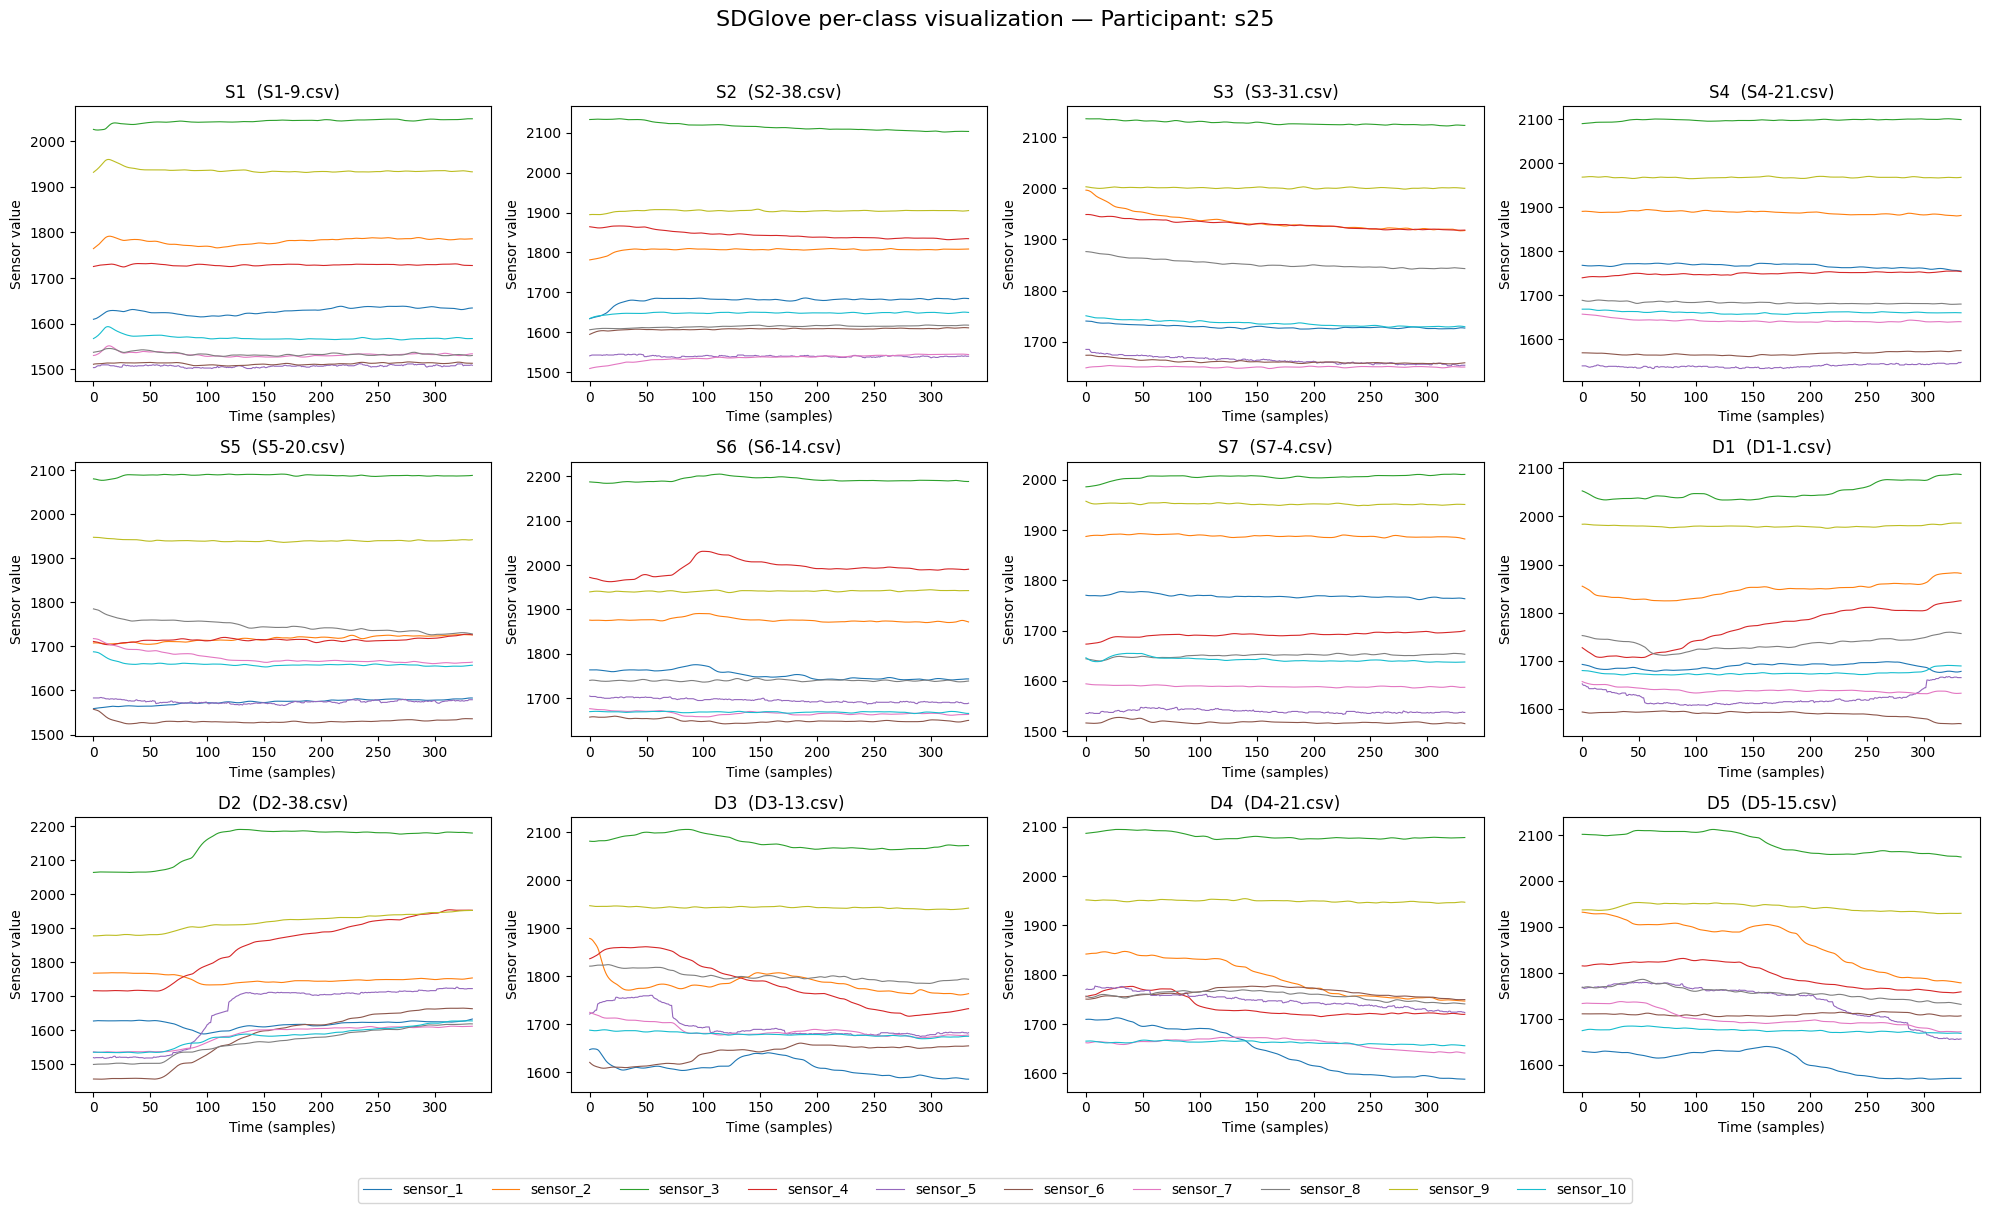

In [4]:
n_rows, n_cols = 3, 4  # 12 classes -> 3x4 grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

for ax, label in zip(axes, ALL_CLASSES):
    file_path = class_files.get(label)
    if file_path is None:
        ax.set_visible(False)
        continue

    df = pd.read_csv(file_path)
    t = np.arange(len(df))
    for col in SENSOR_COLS:
        ax.plot(t, df[col], linewidth=0.8, label=col)

    ax.set_title(f"{label}  ({os.path.basename(file_path)})")
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Sensor value")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f"SDGlove per-class visualization \u2014 Participant: {participant}", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [5]:
# (Optional) save the figure to disk
out_dir = "./figures"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"sdglove_per_class_{participant}.png")
fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"Saved: {out_path}")

Saved: ./figures/sdglove_per_class_s25.png
